<a href="https://colab.research.google.com/github/moniml/mlopstraining/blob/main/log_reg_own.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
df=pd.read_csv("/content/social_media_addiction_dataset (1).csv")
df.head()

,daily_screen_time,app_opens,sleep_hours,stress_level,study_interruptions,night_usage,addiction_level
0,5.4,67,3.8,1,2,No,Moderate
1,4.3,10,6.9,2,7,No,Low
2,7.0,48,5.4,9,3,No,Moderate
3,12.0,16,6.7,2,0,No,Low
4,8.8,25,6.0,3,15,No,Moderate


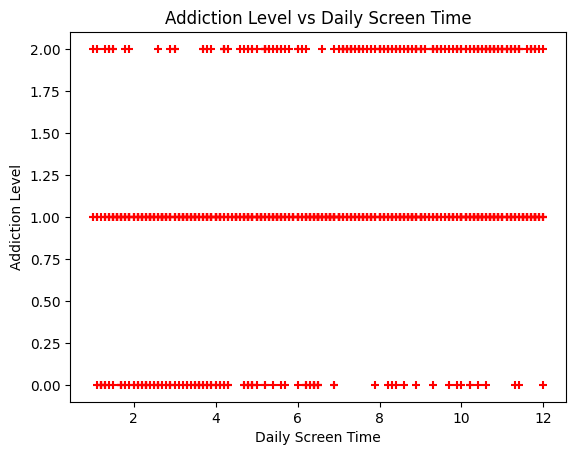

In [ ]:
df['addiction_level_num'] = df['addiction_level'].map({
    'Low':0,
    'Moderate':1,
    'High':2
})

plt.scatter(df.daily_screen_time, df.addiction_level_num, color='red',marker='+')
plt.title("Addiction Level vs Daily Screen Time")
plt.xlabel("Daily Screen Time")
plt.ylabel("Addiction Level")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df[['daily_screen_time']],df.addiction_level,train_size=0.8)

In [ ]:
x_test

,daily_screen_time
716,12.0
740,5.3
146,3.8
706,6.4
280,9.4
...,...
483,8.3
876,10.4
999,5.0
945,1.5


In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [ ]:
model.fit(x_train,y_train);

In [ ]:
x_test

,daily_screen_time
716,12.0
740,5.3
146,3.8
706,6.4
280,9.4
...,...
483,8.3
876,10.4
999,5.0
945,1.5


In [ ]:
y_predicted=model.predict(x_test)

In [ ]:
model.predict_proba(x_test)

array([[0.42488766, 0.01538837, 0.55972397],
       [0.13595841, 0.13079875, 0.73324284],
       [0.09616374, 0.19278681, 0.71104945],
       [0.17121823, 0.09614144, 0.73264033],
       [0.29362527, 0.03796795, 0.66840677],
       [0.17468476, 0.09340234, 0.73191289],
       [0.10093551, 0.18348229, 0.7155822 ],
       [0.06180249, 0.28474504, 0.65345247],
       [0.37245654, 0.02200762, 0.60553585],
       [0.19267142, 0.08065487, 0.72667371],
       [0.08709544, 0.21236989, 0.70053467],
       [0.1644161 , 0.10181711, 0.73376679],
       [0.04776718, 0.34190143, 0.61033139],
       [0.27521552, 0.04328409, 0.6815004 ],
       [0.18174874, 0.08811673, 0.73013453],
       [0.33704447, 0.02805368, 0.63490185],
       [0.11891768, 0.15345863, 0.7276237 ],
       [0.1301085 , 0.13804446, 0.73184704],
       [0.32228418, 0.03106815, 0.64664767],
       [0.09155108, 0.20241619, 0.70603273],
       [0.38799229, 0.0197946 , 0.5922131 ],
       [0.15778842, 0.10776243, 0.73444916],
       [0.

In [ ]:
model.score(x_test,y_test)

0.71

In [ ]:
y_predicted

array(['Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Moderate',
       'Moderate', 'Moderate', 'Moderate', 'Moderate', 'Modera

In [ ]:
x_test

,daily_screen_time
716,12.0
740,5.3
146,3.8
706,6.4
280,9.4
...,...
483,8.3
876,10.4
999,5.0
945,1.5


In [ ]:
model.coef_

array([[ 0.23328521],
       [-0.25619595],
       [ 0.02291074]])

In [ ]:
model.intercept_

array([-1.78522453,  0.77033648,  1.01488805])

In [ ]:
import math
def sigmoid(x):
  return 1/(1+math.exp(-x))

In [ ]:
def prediction_function(daily_screen_time,
                        app_opens,
                        sleep_hours,
                        stress_level,
                        study_interruptions,
                        night_usage_yes):

    z = (
        0.060463 * daily_screen_time +
        0.009285 * app_opens +
        (-0.116149) * sleep_hours +
        0.074095 * stress_level +
        0.036313 * study_interruptions +
        0.250524 * night_usage_yes +
        0.178467
    )

    y = sigmoid(z)
    return y

In [ ]:
prediction_function(8, 65, 5, 8, 6, 1)

0.8514618666687359

In [ ]:
new_data = pd.DataFrame([[8]], columns=['daily_screen_time'])
prediction = model.predict(new_data)
probability = model.predict_proba(new_data)
print("Prediction:", prediction)
print("Probabilities:", probability)

Prediction: ['Moderate']
Probabilities: [[0.23187776 0.05949677 0.70862547]]
